<a href="https://colab.research.google.com/github/Gegee-notavailable/thai-fake-news-detection-TFSVM/blob/main/3parameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip -q install pythainlp peft datasets accelerate evaluate
!pip -q install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.9/21.9 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 46.5 MB/s eta 0:00:00


In [6]:
import random, gc
import numpy as np, pandas as pd, torch
from transformers import set_seed
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support

SEED = 42
EPOCHS_LIST = [10, 20, 30, 40, 50]
MAX_EPOCH = max(EPOCHS_LIST)
AVERAGE = "binary"   # "binary" = ข่าวปลอมเป็น positive class | "macro" = เฉลี่ยสองคลาส

def seed_all(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s); set_seed(s)
seed_all()

RESULTS = []
def prf(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average=AVERAGE, zero_division=0)
    return p, r, f

def add_result(model, epochs, y_true, y_pred):
    p, r, f = prf(y_true, y_pred)
    RESULTS.append(dict(model=model, epochs=epochs, P=p, R=r, F1=f))
    print(f"{model} | epochs={epochs} | P={p:.4f} R={r:.4f} F1={f:.4f}")

In [7]:
from datasets import load_dataset

df = load_dataset("EXt1/Thai-True-Fake-News")["train"].to_pandas()
print(df.columns.tolist())
print(df["Verification_Status"].value_counts())

df = df[["Title", "Verification_Status"]].dropna().drop_duplicates(subset="Title")
df["label"] = (df["Verification_Status"] == "ข่าวปลอม").astype(int)   # 1 = ข่าวปลอม
df = df.reset_index(drop=True)

train_df, tmp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(tmp_df, test_size=0.5, stratify=tmp_df["label"], random_state=SEED)
print(len(train_df), len(val_df), len(test_df))

README.md:   0%|          | 0.00/747 [00:00<?, ?B/s]

dataset.csv:   0%|          | 0.00/1.44M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6004 [00:00<?, ? examples/s]

['Unnamed: 0', 'Title', 'Verification_Status']
Verification_Status
ข่าวปลอม    3002
ข่าวจริง    3002
Name: count, dtype: int64
4599 575 575


In [8]:
from pythainlp.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier

tok_th = lambda t: word_tokenize(t, engine="newmm", keep_whitespace=False)
tfidf = TfidfVectorizer(tokenizer=tok_th, token_pattern=None,
                        ngram_range=(1, 2), min_df=2, sublinear_tf=True)
Xtr = tfidf.fit_transform(train_df["Title"])
Xva = tfidf.transform(val_df["Title"])

for e in EPOCHS_LIST:
    clf = SGDClassifier(loss="hinge", max_iter=e, tol=None, random_state=SEED)
    clf.fit(Xtr, train_df["label"])
    add_result("TF-IDF+SVM", e, val_df["label"], clf.predict(Xva))

TF-IDF+SVM | epochs=10 | P=0.8993 R=0.9058 F1=0.9025
TF-IDF+SVM | epochs=20 | P=0.9158 R=0.9058 F1=0.9107
TF-IDF+SVM | epochs=30 | P=0.9091 R=0.9058 F1=0.9074
TF-IDF+SVM | epochs=40 | P=0.9191 R=0.9058 F1=0.9124
TF-IDF+SVM | epochs=50 | P=0.9191 R=0.9058 F1=0.9124


In [16]:
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)

def hf_metrics(eval_pred):
    logits, labels = eval_pred
    p, r, f = prf(labels, np.argmax(logits, axis=-1))
    return {"P": p, "R": r, "F1": f}

def run_hf(model_name, tag, lr, batch_size, lora=False, max_len=64):
    seed_all()
    tok = AutoTokenizer.from_pretrained(model_name)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    def enc(d):
        ds = Dataset.from_pandas(d[["Title", "label"]].reset_index(drop=True))
        ds = ds.map(lambda b: tok(b["Title"], truncation=True, max_length=max_len), batched=True)
        return ds.remove_columns(["Title"]).rename_column("label", "labels")
    tr_ds, va_ds = enc(train_df), enc(val_df)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, dtype=torch.float32)
    model.config.pad_token_id = tok.pad_token_id
    if lora:
        from peft import LoraConfig, get_peft_model
        cfg = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, task_type="SEQ_CLS",
                         target_modules=["q_proj", "k_proj", "v_proj", "o_proj"])
        model = get_peft_model(model, cfg)
        model.print_trainable_parameters()

    steps_per_epoch = -(-len(tr_ds) // batch_size)   # ปัดขึ้น
    warmup = int(0.05 * steps_per_epoch * MAX_EPOCH)

    args = TrainingArguments(
        output_dir=f"/content/out_{tag}", num_train_epochs=MAX_EPOCH,
        per_device_train_batch_size=batch_size, per_device_eval_batch_size=64,
        learning_rate=lr, weight_decay=0.01, warmup_steps=warmup,
        eval_strategy="epoch", save_strategy="no", logging_strategy="no",
        fp16=torch.cuda.is_available(), seed=SEED, data_seed=SEED, report_to="none")

    trainer = Trainer(model=model, args=args, train_dataset=tr_ds, eval_dataset=va_ds,
                      data_collator=DataCollatorWithPadding(tok), compute_metrics=hf_metrics)
    trainer.train()

    for log in trainer.state.log_history:
        if "eval_F1" in log and int(round(log["epoch"])) in EPOCHS_LIST:
            ep = int(round(log["epoch"]))
            RESULTS.append(dict(model=tag, epochs=ep,
                                P=log["eval_P"], R=log["eval_R"], F1=log["eval_F1"]))
            print(tag, ep, round(log["eval_P"], 4), round(log["eval_R"], 4), round(log["eval_F1"], 4))

    del model, trainer
    gc.collect(); torch.cuda.empty_cache()

In [10]:
run_hf("airesearch/wangchanberta-base-att-spm-uncased", tag="Thai-BERT", lr=2e-5, batch_size=32)

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/282 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/905k [00:00<?, ?B/s]

Map:   0%|          | 0/4599 [00:00<?, ? examples/s]

Map:   0%|          | 0/575 [00:00<?, ? examples/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CamembertForSequenceClassification LOAD REPORT from: airesearch/wangchanberta-base-att-spm-uncased
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,P,R,F1
1,No log,0.506255,0.771739,0.771739,0.771739
2,No log,0.296049,0.823718,0.931159,0.874150
3,No log,0.226275,0.916350,0.873188,0.894249
4,No log,0.244729,0.864238,0.945652,0.903114
5,No log,0.241454,0.908425,0.898551,0.903461
6,No log,0.275566,0.915194,0.938406,0.926655
7,No log,0.332947,0.898601,0.931159,0.914591
8,No log,0.387212,0.885906,0.956522,0.919861
9,No log,0.413078,0.911972,0.938406,0.925000
10,No log,0.427303,0.906810,0.916667,0.911712


Thai-BERT 10 0.9068 0.9167 0.9117
Thai-BERT 20 0.8866 0.9348 0.9101
Thai-BERT 30 0.89 0.9384 0.9136
Thai-BERT 40 0.9191 0.9058 0.9124
Thai-BERT 50 0.9107 0.9239 0.9173


In [17]:
import gc, torch
gc.collect(); torch.cuda.empty_cache()

In [18]:
run_hf("scb10x/llama3.2-typhoon2-1b-instruct", tag="Typhoon-1B-LoRA",
       lr=2e-4, batch_size=16, lora=True)

Map:   0%|          | 0/4599 [00:00<?, ? examples/s]

Map:   0%|          | 0/575 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] LlamaForSequenceClassification LOAD REPORT from: scb10x/llama3.2-typhoon2-1b-instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 3,411,968 || all params: 1,239,230,464 || trainable%: 0.2753


Epoch,Training Loss,Validation Loss,P,R,F1
1,No log,0.036990,0.992806,1.000000,0.996390
2,No log,0.046590,0.996390,1.000000,0.998192
3,No log,0.054093,0.996350,0.989130,0.992727
4,No log,0.029071,0.996377,0.996377,0.996377
5,No log,0.045351,0.992806,1.000000,0.996390
6,No log,0.084671,0.992780,0.996377,0.994575
7,No log,0.090168,0.996350,0.989130,0.992727
8,No log,0.066502,0.992754,0.992754,0.992754
9,No log,0.038162,0.996377,0.996377,0.996377
10,No log,0.054627,0.996377,0.996377,0.996377


Typhoon-1B-LoRA 10 0.9964 0.9964 0.9964
Typhoon-1B-LoRA 20 0.9964 0.9964 0.9964
Typhoon-1B-LoRA 30 0.9964 0.9964 0.9964
Typhoon-1B-LoRA 40 0.9964 0.9964 0.9964
Typhoon-1B-LoRA 50 0.9964 0.9964 0.9964


,model,epochs,P,R,F1
0,TF-IDF+SVM,10,0.8993,0.9058,0.9025
1,TF-IDF+SVM,20,0.9158,0.9058,0.9107
2,TF-IDF+SVM,30,0.9091,0.9058,0.9074
3,TF-IDF+SVM,40,0.9191,0.9058,0.9124
4,TF-IDF+SVM,50,0.9191,0.9058,0.9124
5,Thai-BERT,10,0.9068,0.9167,0.9117
6,Thai-BERT,20,0.8866,0.9348,0.9101
7,Thai-BERT,30,0.8900,0.9384,0.9136
8,Thai-BERT,40,0.9191,0.9058,0.9124
9,Thai-BERT,50,0.9107,0.9239,0.9173


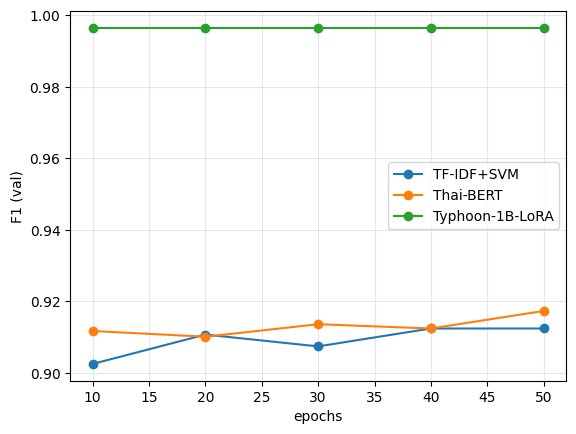

In [19]:
res = pd.DataFrame(RESULTS).sort_values(["model", "epochs"]).reset_index(drop=True)
res[["P", "R", "F1"]] = res[["P", "R", "F1"]].round(4)
display(res)
res.to_csv("results.csv", index=False)

import matplotlib.pyplot as plt
for m, g in res.groupby("model"):
    plt.plot(g["epochs"], g["F1"], marker="o", label=m)
plt.xlabel("epochs"); plt.ylabel("F1 (val)"); plt.legend(); plt.grid(alpha=.3)
plt.savefig("f1_vs_epochs.png", dpi=150, bbox_inches="tight")
plt.show()